# Phase 3 — EDA

Dataset: Online Retail II (UCI)


In [1]:
import os

cwd = os.getcwd()
if cwd.endswith("notebooks"):
    os.chdir("..")

os.makedirs("reports/figures", exist_ok=True)
print("working dir:", os.getcwd())


Current directory: C:\Users\91832\Desktop\ecommerce-forecasting\notebooks
Moved to project root: C:\Users\91832\Desktop\ecommerce-forecasting
✅ reports/figures/ folder ready


## 3.1 — Load & Check Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


✅ All libraries imported successfully


In [3]:
df = pd.read_csv(
    "data/processed/online_retail_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

print(f"shape: {df.shape}")
print(f"date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


✅ Data loaded successfully
   Shape    : (1007913, 15)  (rows, columns)
   Columns  : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'WeekOfYear', 'TotalPrice']
   Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [4]:
display(df.head())
print(df.dtypes)
print(df.isnull().sum())
display(df[["Quantity", "Price", "TotalPrice"]].describe().round(2))


=== First 5 rows ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,DayOfWeek,Hour,WeekOfYear,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,1,7,49,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,1,7,49,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,1,7,49,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,1,7,49,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,1,7,49,30.0



=== Data Types ===
Invoice                object
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Year                    int64
Month                   int64
Day                     int64
DayOfWeek               int64
Hour                    int64
WeekOfYear              int64
TotalPrice            float64
dtype: object

=== Null Values ===
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    228488
Country             0
Year                0
Month               0
Day                 0
DayOfWeek           0
Hour                0
WeekOfYear          0
TotalPrice          0
dtype: int64

=== Basic Stats ===


,Quantity,Price,TotalPrice
count,1007913.00,1007913.00,1007913.00
mean,11.12,4.07,20.32
std,128.47,50.43,205.72
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.08
75%,12.00,4.13,17.70
max,80995.00,25111.09,168469.60


In [5]:
# making sure the time columns from phase 2 are still there
# sometimes they get lost if the csv save/load doesn't behave
required_cols = ["Year", "Month", "Day", "DayOfWeek", "Hour", "WeekOfYear", "TotalPrice"]
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print(f"missing cols: {missing} - recreating")
    df["Year"]       = df["InvoiceDate"].dt.year
    df["Month"]      = df["InvoiceDate"].dt.month
    df["Day"]        = df["InvoiceDate"].dt.day
    df["Hour"]       = df["InvoiceDate"].dt.hour
    df["WeekOfYear"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)
    df["TotalPrice"] = df["Quantity"] * df["Price"]

    day_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
    df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek.map(day_map)
else:
    print("all columns present")

# need this for grouping by month in charts
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")


✅ All required columns present — no action needed
✅ YearMonth column ready


## 3.2 — Sales Trends


In [6]:
# group by month to see overall revenue trend
monthly_revenue = (
    df.groupby("YearMonth")["TotalPrice"]
    .sum()
    .reset_index()
)

# plotly doesn't like Period type so converting to string
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)
monthly_revenue["TotalPrice"] = monthly_revenue["TotalPrice"].round(2)

fig_monthly = px.line(
    monthly_revenue,
    x="YearMonth",
    y="TotalPrice",
    title="Monthly Revenue Trend",
    labels={"YearMonth": "Month", "TotalPrice": "Total Revenue (£)"},
    markers=True
)
fig_monthly.update_layout(xaxis_tickangle=-45)
fig_monthly.write_html("reports/figures/monthly_revenue.html")
fig_monthly.show()


✅ Saved: reports/figures/monthly_revenue.html


In [7]:
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

dow_revenue = (
    df.groupby("DayOfWeek")["TotalPrice"]
    .sum()
    .reindex(day_order)
    .reset_index()
)
dow_revenue.columns = ["DayOfWeek", "TotalRevenue"]
dow_revenue["TotalRevenue"] = dow_revenue["TotalRevenue"].round(2)

# expecting weekdays to dominate since this is a B2B wholesale business
fig_dow = px.bar(
    dow_revenue,
    x="DayOfWeek",
    y="TotalRevenue",
    title="Revenue by Day of Week",
    labels={"DayOfWeek": "Day", "TotalRevenue": "Total Revenue (£)"},
    color="TotalRevenue",
    color_continuous_scale="Blues",
    text="TotalRevenue"
)
fig_dow.write_html("reports/figures/revenue_by_dow.html")
fig_dow.show()


✅ Saved: reports/figures/revenue_by_dow.html


## 3.3 — Top Products & Countries


In [8]:
# some entries aren't real products - postage, manual adjustments etc.
# removing them before doing product analysis otherwise they'll show up as top items
non_products = ["Manual", "DOTCOM POSTAGE", "POSTAGE", "Adjust bad debt"]

df_products_only = df[~df["Description"].isin(non_products)]

print(f"rows before: {len(df):,}")
print(f"rows after: {len(df_products_only):,}")


Rows before filter : 1,007,913
Rows after filter  : 1,003,795
Rows removed       : 4,118


In [9]:
top_products = (
    df_products_only.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_products.columns = ["Product", "TotalRevenue"]
top_products["TotalRevenue"] = top_products["TotalRevenue"].round(2)

print(top_products)

fig_prod = px.bar(
    top_products,
    x="TotalRevenue",
    y="Product",
    orientation="h",
    title="Top 10 Products by Total Revenue",
    labels={"TotalRevenue": "Total Revenue (£)", "Product": ""},
    color="TotalRevenue",
    color_continuous_scale="Blues",
    text="TotalRevenue"
)
fig_prod.update_layout(yaxis={"categoryorder": "total ascending"})
fig_prod.write_html("reports/figures/top10_products.html")
fig_prod.show()


                               Product  TotalRevenue
0             REGENCY CAKESTAND 3 TIER     330590.32
1   WHITE HANGING HEART T-LIGHT HOLDER     260990.22
2          PAPER CRAFT , LITTLE BIRDIE     168469.60
3                        PARTY BUNTING     148318.28
4              JUMBO BAG RED RETROSPOT     148073.47
5        ASSORTED COLOUR BIRD ORNAMENT     129324.49
6      PAPER CHAIN KIT 50'S CHRISTMAS      117760.29
7       MEDIUM CERAMIC TOP STORAGE JAR      81700.92
8                        CHILLI LIGHTS      80540.88
9  ROTATING SILVER ANGELS T-LIGHT HLDR      71300.40


✅ Saved: reports/figures/top10_products.html


In [10]:
# UK dominates so much that it makes the chart useless if included
# showing it separately then plotting international markets
uk_revenue = df[df["Country"] == "United Kingdom"]["TotalPrice"].sum()
print(f"UK total revenue: £{uk_revenue:,.2f}")

top_countries = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_countries.columns = ["Country", "TotalRevenue"]
top_countries["TotalRevenue"] = top_countries["TotalRevenue"].round(2)

total_non_uk = top_countries["TotalRevenue"].sum()
top_countries["RevenueShare%"] = (top_countries["TotalRevenue"] / total_non_uk * 100).round(2)
print(top_countries)

fig_ctry = px.bar(
    top_countries,
    x="TotalRevenue",
    y="Country",
    orientation="h",
    title="Top 10 Countries by Revenue (Excluding UK)",
    labels={"TotalRevenue": "Total Revenue (£)", "Country": ""},
    color="TotalRevenue",
    color_continuous_scale="Greens",
    text="TotalRevenue"
)
fig_ctry.update_layout(yaxis={"categoryorder": "total ascending"})
fig_ctry.write_html("reports/figures/top10_countries.html")
fig_ctry.show()


🇬🇧 UK Total Revenue: £17,410,196.12
       Country  TotalRevenue  RevenueShare%
0         EIRE     658767.31          25.41
1  Netherlands     554038.09          21.37
2      Germany     425019.71          16.39
3       France     350456.09          13.52
4    Australia     169283.46           6.53
5        Spain     108332.49           4.18
6  Switzerland     100685.59           3.88
7       Sweden      91869.82           3.54
8      Denmark      68580.69           2.65
9      Belgium      65387.82           2.52


✅ Saved: reports/figures/top10_countries.html


## 3.4 — Customer RFM Analysis


In [11]:
# RFM = Recency, Frequency, Monetary
# scoring each customer on how recently they bought, how often, and how much
# snapshot date is 1 day after the last transaction so the most recent customer gets recency=1

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"snapshot date: {snapshot_date}")
print(f"date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


Snapshot date     : 2011-12-10 12:50:00
Dataset date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [12]:
rfm = (
    df.groupby("Customer ID")
    .agg(
        Recency   = ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency = ("Invoice",     "nunique"),  # unique orders, not rows
        Monetary  = ("TotalPrice",  "sum")
    )
    .reset_index()
)

rfm["Monetary"] = rfm["Monetary"].round(2)

print(f"unique customers: {len(rfm):,}")
display(rfm.head(10))
display(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))


Total unique customers: 5,878

First 10 rows:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61



RFM Summary Statistics:


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


In [13]:
# splitting each metric into 5 buckets (quintiles)
# score 5 = best, 1 = worst
# recency is reversed - smaller number (bought recently) should get score 5

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])

# using rank() to handle ties in frequency and monetary
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"),  q=5, labels=[1, 2, 3, 4, 5])

rfm["RFM_Segment"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
) / 3

display(rfm[["Customer ID", "Recency", "Frequency", "Monetary",
             "R_Score", "F_Score", "M_Score", "RFM_Segment", "RFM_Score"]].head(10))


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255,4.000000
1,12347.0,2,8,4921.53,5,4,5,545,4.666667
2,12348.0,75,5,2019.40,3,4,4,344,3.666667
3,12349.0,19,4,4428.69,5,3,5,535,4.333333
4,12350.0,310,1,334.40,2,1,2,212,1.666667
5,12351.0,375,1,300.93,2,1,2,212,1.666667
6,12352.0,36,10,2849.84,4,5,4,454,4.333333
7,12353.0,204,2,406.76,2,2,2,222,2.000000
8,12354.0,232,1,1079.40,2,1,3,213,2.000000
9,12355.0,214,2,947.61,2,2,3,223,2.333333


In [14]:
def label_segment(score):
    if score >= 4.5:   return "Champions"
    elif score >= 4.0: return "Loyal Customers"
    elif score >= 3.0: return "Potential Loyalists"
    elif score >= 2.0: return "At Risk"
    else:              return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(label_segment)

segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "CustomerCount"]
print(segment_counts)

fig_rfm = px.bar(
    segment_counts,
    x="Segment",
    y="CustomerCount",
    title="Customer Segments by RFM Score",
    color="Segment",
    text="CustomerCount",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig_rfm.write_html("reports/figures/rfm_segments.html")
fig_rfm.show()


               Segment  CustomerCount
0  Potential Loyalists           1436
1              At Risk           1410
2                 Lost           1308
3      Loyal Customers            866
4            Champions            858


✅ Saved: reports/figures/rfm_segments.html


## 3.5 — Outlier Detection


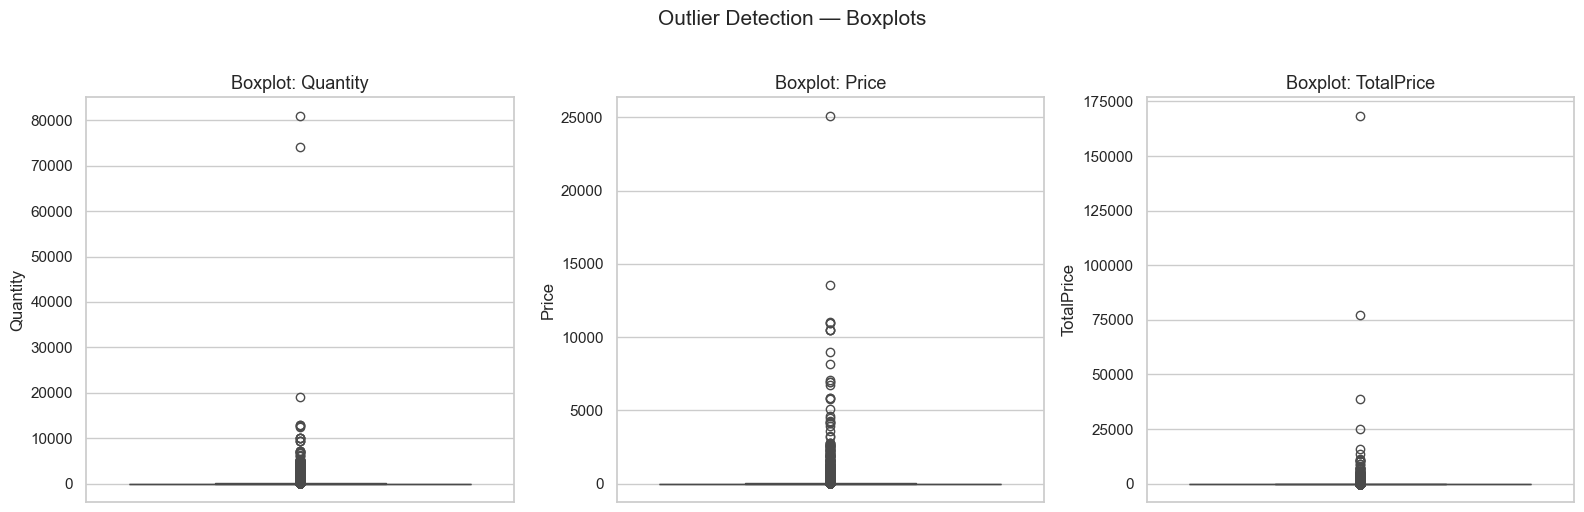

✅ Saved: reports/figures/outlier_boxplots.png


In [15]:
cols_to_check = ["Quantity", "Price", "TotalPrice"]

fig_box, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=df[col], ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

plt.suptitle("Outlier Detection", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# IQR method - anything outside 1.5*IQR from Q1/Q3 is flagged as outlier
print("outlier counts (IQR method)\n")

for col in cols_to_check:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = (len(outliers) / len(df)) * 100

    print(f"{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  fences: [{lower:.2f}, {upper:.2f}]")
    print(f"  outliers: {len(outliers):,} ({pct:.2f}%)\n")


=== Outlier Count per Column (IQR Method) ===

📊 Quantity:
   Q1=1.00  |  Q3=12.00  |  IQR=11.00
   Lower fence=-15.50  |  Upper fence=28.50
   ⚠️  Outlier rows: 53,061  (5.26% of data)

📊 Price:
   Q1=1.25  |  Q3=4.13  |  IQR=2.88
   Lower fence=-3.07  |  Upper fence=8.45
   ⚠️  Outlier rows: 78,999  (7.84% of data)

📊 TotalPrice:
   Q1=4.13  |  Q3=17.70  |  IQR=13.57
   Lower fence=-16.23  |  Upper fence=38.06
   ⚠️  Outlier rows: 84,954  (8.43% of data)



In [17]:
# looking at the actual transactions before deciding what to do with outliers
# if they have valid invoice numbers they're probably genuine bulk orders
print("top 10 highest value transactions:")
top_txn = (
    df[["Invoice", "Customer ID", "Description",
        "Quantity", "Price", "TotalPrice", "Country"]]
    .sort_values("TotalPrice", ascending=False)
    .head(10)
)
display(top_txn)


=== Top 10 Highest TotalPrice Transactions ===



,Invoice,Customer ID,Description,Quantity,Price,TotalPrice,Country
1006438,581483,16446.0,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
542683,541431,12346.0,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
698499,556444,15098.0,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
231523,512771,NaN,Manual,1,25111.09,25111.09,United Kingdom
414827,530715,15838.0,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,15818.40,United Kingdom
497490,537632,NaN,AMAZON FEE,1,13541.33,13541.33,United Kingdom
773540,A563185,NaN,Adjust bad debt,1,11062.06,11062.06,United Kingdom
129383,502265,NaN,Manual,1,10953.50,10953.50,United Kingdom
129382,502263,12918.0,Manual,1,10953.50,10953.50,United Kingdom
357810,525399,NaN,Manual,1,10468.80,10468.80,United Kingdom


In [18]:
# decided to flag rather than drop - these bulk orders really did happen
# dropping them would make the model underestimate demand during busy periods

Q1_tp  = df["TotalPrice"].quantile(0.25)
Q3_tp  = df["TotalPrice"].quantile(0.75)
IQR_tp = Q3_tp - Q1_tp
upper_fence_tp = Q3_tp + 1.5 * IQR_tp

df["IsPriceOutlier"] = df["TotalPrice"] > upper_fence_tp

total_flagged   = df["IsPriceOutlier"].sum()
pct_flagged     = df["IsPriceOutlier"].mean() * 100
outlier_revenue = df[df["IsPriceOutlier"]]["TotalPrice"].sum()
total_revenue   = df["TotalPrice"].sum()

print(f"rows flagged: {total_flagged:,} ({pct_flagged:.2f}%)")
print(f"outlier revenue: £{outlier_revenue:,.2f} ({(outlier_revenue/total_revenue)*100:.2f}% of total)")


✅ 'IsPriceOutlier' column added to dataframe
   Rows flagged    : 84,954  (8.43% of rows)
   Outlier revenue : £10,658,168.60  (52.05% of total revenue)

💡 Key Insight: Even if outlier ROWS are few, they often carry
   disproportionate revenue — very typical in B2B wholesale.


## 3.6 — Correlation


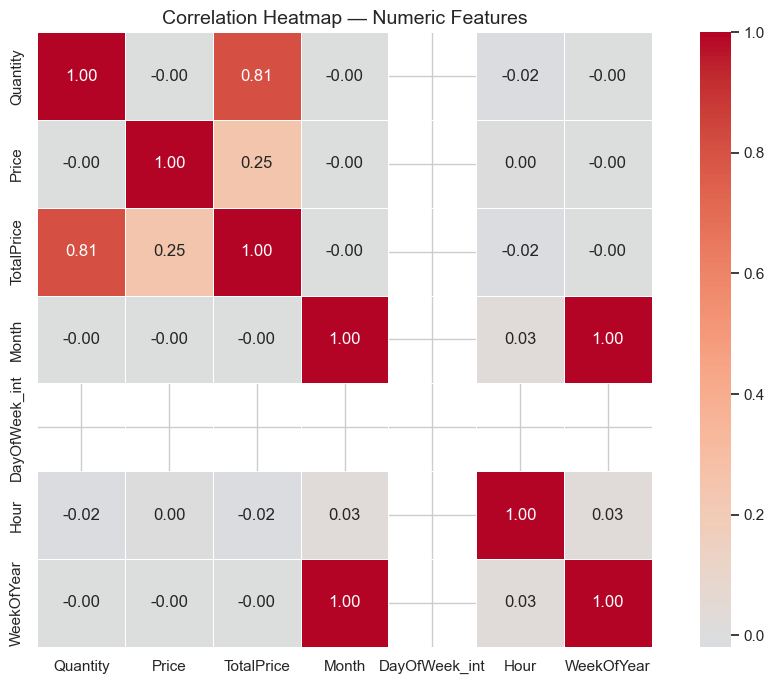

✅ Saved: reports/figures/correlation_heatmap.png


In [19]:
numeric_cols = ["Quantity", "Price", "TotalPrice",
                "Month", "DayOfWeek_int", "Hour", "WeekOfYear"]

# DayOfWeek is strings so need int version for correlation
day_to_int = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4, "Sat": 5, "Sun": 6}
df["DayOfWeek_int"] = df["DayOfWeek"].map(day_to_int)

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
hourly = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
    .reset_index()
)
hourly.columns = ["Hour", "TotalRevenue"]

fig_hour = px.line(
    hourly,
    x="Hour",
    y="TotalRevenue",
    title="Revenue by Hour of Day",
    labels={"Hour": "Hour (24h)", "TotalRevenue": "Total Revenue (£)"},
    markers=True
)
fig_hour.write_html("reports/figures/revenue_by_hour.html")
fig_hour.show()


✅ Saved: reports/figures/revenue_by_hour.html


In [21]:
weekly = (
    df.groupby("WeekOfYear")["TotalPrice"]
    .sum()
    .reset_index()
)
weekly.columns = ["WeekOfYear", "TotalRevenue"]

# expecting a dip around week 52 (christmas shutdown)
fig_week = px.bar(
    weekly,
    x="WeekOfYear",
    y="TotalRevenue",
    title="Revenue by Week of Year",
    labels={"WeekOfYear": "Week", "TotalRevenue": "Total Revenue (£)"},
    color="TotalRevenue",
    color_continuous_scale="Viridis"
)
fig_week.write_html("reports/figures/revenue_by_week.html")
fig_week.show()


✅ Saved: reports/figures/revenue_by_week.html


In [22]:
# AOV = total revenue / number of unique orders per country
# different from just total revenue - some countries buy less often but in bigger amounts

aov = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")
    .agg(
        TotalRevenue = ("TotalPrice", "sum"),
        OrderCount   = ("Invoice",    "nunique")
    )
    .reset_index()
)
aov["AOV"] = (aov["TotalRevenue"] / aov["OrderCount"]).round(2)

top_aov = aov.sort_values("AOV", ascending=False).head(15)

fig_aov = px.bar(
    top_aov,
    x="Country",
    y="AOV",
    title="Average Order Value by Country (excl. UK) - Top 15",
    labels={"AOV": "Avg Order Value (£)"},
    color="AOV",
    color_continuous_scale="Teal",
    text="AOV"
)
fig_aov.update_layout(xaxis_tickangle=-35)
fig_aov.write_html("reports/figures/aov_by_country.html")
fig_aov.show()


✅ Saved: reports/figures/aov_by_country.html


In [23]:
output_path = "data/processed/online_retail_eda_complete.csv"
df.to_csv(output_path, index=False)

print(f"saved: {output_path}")
print(f"shape: {df.shape}")


✅ Final dataset saved to: data/processed/online_retail_eda_complete.csv
   Shape  : (1007913, 18)
   Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'WeekOfYear', 'TotalPrice', 'YearMonth', 'IsPriceOutlier', 'DayOfWeek_int']


## Phase 3 done
